# DATA 532 Lab 1

### A note for this lab
#### This lab will be graded based on the following rubrics:
   - **1) Code** : 
      - Accuracy: The code runs perfectly and the output is clear without being unnecessarily verbose.  
      - Quality: Code readability is exceptional and code functionality is unambiguous. For example:
         * Variable names are clear and self-documenting, an appropriate amount of whitespace is used to maximize visibility, tabs and spaces are not mixed for indentation, sufficient comments are given.
         * All functions have proper documentation (docstrings in Python). 
         * Overall, code organization and documentation is impeccable. 
         * Code repetition is minimized via the use of loops/mapping functions, functions or classes or scripts/files as needed without becoming overly complicated. 
         * Functions are short, concise, and cohesive without losing clarity; code can be easily modified. 
         * Tests are present to ensure functions work as expected. Exceptions are caught and thrown if necessary.
      - Efficiency: Code is as fast as it can reasonably be given the specifications of the problem.
   - **2) Reasoning**: Mastery of the learning material is demonstrated, original ideas may be presented.  In the case of short-answer questions, the correct method was used and the correct result attained. Analysis is thorough and exhaustive without being drawn out or lacking focus. Thesis is clear and the arguments that support it are flawless and very well-reasoned, leaving no obvious gaps, and are communicated clearly.
    
### Exercise 1 - searching in arrays (2.5 marks)
1. Write a Python function `search_unsorted` that takes in an unsorted list/array and a value, and searches to see if that value is in the array. You should use a loop to do this. (0.5 mark) 
2. Write a Python function `search_sorted` that takes in an _sorted_ list/array and a value, and searches to see if that value is in the array. Use binary search for this. (1 mark) 
3. What is the time complexity of these two operations? Answer in big-O notatio and explain your answer. You can use LaTeX directly within Markdown here, to write equations. For example, $\mathcal{O}(n^3)$ is written as `$\mathcal{O}(n^3)$`. (0.5 mark)
4. Test your answer above empirically. Some further info: (0.5 mark)
   * Generate the array with random integers between 0 and $10^7$ using `numpy.random.randint` 
   * check to see if the number 999 is in the array
   * To sort the array, use `array.sort()`
   * To time a line of code, you can use `timeit`. An example is given below.
   * Use array sizes $10^2$, $10^3$, $10^4$, $10^5$, $10^6$, and $10^7$
   * Present your results in a Markdown table. A skeleton of the table is given below
   * Create a visualization by plotting your results on a log-log scale (logarithmic scale for both x and y axes). This will help you see the performance characteristics of each algorithm more clearly.

Note: Python already has syntax for checking whether an array contains a particular value. The syntax is `key in data`. Empirically measure the speed of this method and compare it with your two functions. Try to explain your observations.

In [4]:
def search_unsorted(data, key):
    
    valueIsInList = False
    for element in data:
        
        if element == key:
            valueIsInList = True
            break

    if valueIsInList:
        return True
    else:
        return False

In [5]:
def search_sorted(data, key):
    
    lowerInd = 0
    upperInd = len(data) - 1

    valueIsInList = False
    while lowerInd <= upperInd and not valueIsInList:

        midInd = (lowerInd + upperInd) // 2
        
        if data[midInd] > key:
            upperInd = midInd - 1
            
        elif data[midInd] < key:
            lowerInd = midInd + 1
            
        elif data[midInd] == key:
            valueIsInList = True

    if valueIsInList:
        return True
    else:
        return False

The time complexity of search_unsorted is $\mathcal{O}(n)$ because in the worst case scenario you'd have to loop through every record, and there are n records.

The time search_sorted takes to run depends on the number of comparisons (k). In the worst case scenario the number of comparisons (k) can be expressed as $2^k = n$ which gives $k=log_2(n)$, so the time complexity of search_sorted is $\mathcal{O}(log(n))$.

In [8]:
import numpy.random as npr

testLengths = [1e2, 1e3, 1e4, 1e5, 1e6, 1e7]

for testLength in testLengths:
    print(f'Length of test list: {testLength}')

    testLength = int(testLength)
    x = npr.randint(testLength, size=testLength)

    print('Unsorted:')
    %timeit search_unsorted(x, 999)
    
    x.sort()
    print('Sorted:')
    %timeit search_sorted(x, 999)     

    print('In:')
    %timeit 999 in x
    
    print('\n')

Length of test list: 100.0
Unsorted:
2.97 μs ± 17.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Sorted:
864 ns ± 29 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
In:
903 ns ± 10.1 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Length of test list: 1000.0
Unsorted:
5.93 μs ± 343 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
Sorted:
1.34 μs ± 35.8 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
In:
1.04 μs ± 36.5 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Length of test list: 10000.0
Unsorted:
24.5 μs ± 582 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
Sorted:
1.3 μs ± 34.7 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
In:
1.73 μs ± 120 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Length of test list: 100000.0
Unsorted:
3.23 ms ± 324 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Sorted:
1.55 μs ± 31.7 ns per loop (mean ± std

My results:

| Array size |  Time spent when unsorted | Time spent when sorted | Time spent by Python's `in` |
|------------|---------------------------|------------------------|-----------------------------|
| 10^2       | 2.97 μs                   | 864 ns                 | 903 ns                      |
| 10^3       | 5.93 μs                   | 1.34 μs                | 1.04 μs                     |
| 10^4       | 24.5 μs                   | 1.30 μs                | 1.73 μs                     |
| 10^5       | 3.23 ms                   | 1.55 μs                | 9.52 μs                     |
| 10^6       | 3.72 ms                   | 969 ns                 | 84.9 μs                     |
| 10^7       | 329 ms                    | 2.36 μs                | 1.47 ms                     |

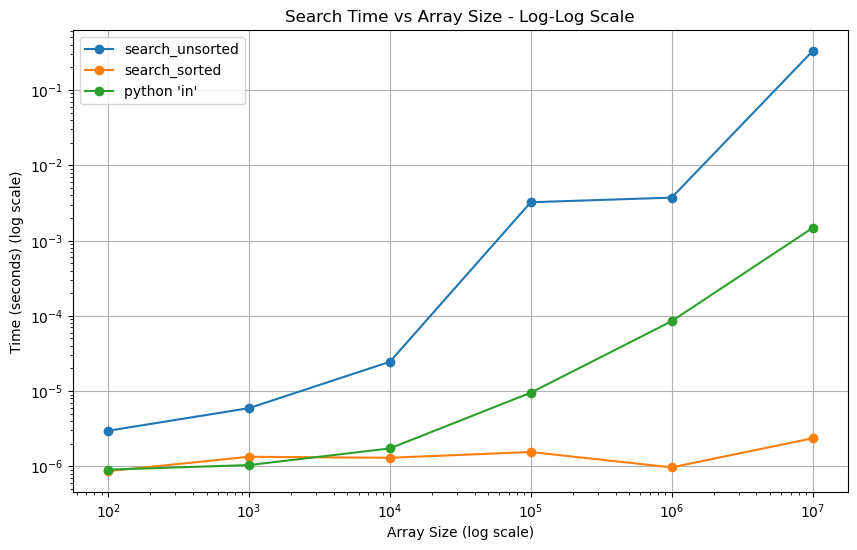

In [10]:
import matplotlib.pyplot as plt

array_sizes = [10**2, 10**3, 10**4, 10**5, 10**6, 10**7]
unsorted_times = [2.97e-6, 5.93e-6, 24.5e-6, 3.23e-3, 3.72e-3, 329e-3]
sorted_times = [864e-9, 1.34e-6, 1.30e-6, 1.55e-6, 969e-9, 2.36e-6]
python_in_times = [903e-9, 1.04e-6, 1.73e-6, 9.52e-6, 84.9e-6, 1.47e-3]

plt.figure(figsize=(10, 6))
plt.plot(array_sizes, unsorted_times, label='search_unsorted', marker='o')
plt.plot(array_sizes, sorted_times, label='search_sorted', marker='o')
plt.plot(array_sizes, python_in_times, label="python 'in'", marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Array Size (log scale)')
plt.ylabel('Time (seconds) (log scale)')
plt.title('Search Time vs Array Size - Log-Log Scale')
plt.legend()
plt.grid(True)
plt.show()

### Exercise 2 - More practice with complexity (2.5 marks)

For each of the following functions, determine the time complexity AND memory complexity, as a function of the input $N$. If you get stuck, it's fair game to test things empirically and then try to understand what you observe. **Please state your assumptions if you don’t know how long some operation in Python takes.** 

You can refer to [this](https://wiki.python.org/moin/TimeComplexity) link where you can find the time-complexity of various operations. It is not necessary to refer to this link. You can also have your own reasonable assumptions. 

The first question is done for you, as an example.

In [18]:
def test(N):
    for i in range(N):
        print(i)
        print(i**2)
        x = 9
        y = 10

_Sample answer_

The time complexity of `test` is $O(N)$ because the lines of code will be executed N times, and the times these lines will be executed will grow linearly with the grow of N

The memory complexity of `test` is $O(1)$ because we store a constant amount (independent of $N$) 

In [19]:
def bar(N):
    i = 0
    while i < N:
        j = 0
        while j < N:
            j = j + 1
        i = i + 1

The time complexity of `bar` is $O(N^2)$ because each loop runs N times and there are two loops, therefore $NxN=N^2$ total iterations.

The memory complexity of `bar` is $O(1)$ because the integers i and j are the only two variables being set no matter how big N is.

In [ ]:
def foo(N):
    i = 0
    j = 0
    while i < N:
        while j < N:
            j = j + 1
        i = i + 1

The time complexity of `foo` is $O(N)$ because the inner loop only runs N time, not N times for each iteration of the outer loop, which also runs N times. Therefore the time only scales with N.

The memory complexity of `foo` is $O(1)$ because the integers i and j are the only two variables being set no matter how big N is.

In [ ]:
def bat(N):
    return "A"*N

The time complexity of `bat` is $O(N)$ because "A" is being added to itself N times.

The memory complexity of `bat` is $O(N)$ because the final string of length N will require N times more memory.

In [ ]:
def oh(N):
    i = 0
    while i < N:
        i = i + 1

The time complexity of `oh` is $O(N)$ because the loop runs N times.

The memory complexity of `oh` is $O(1)$ because the integer i is the only variable being set no matter how big N is.

In [ ]:
def oh_no(N):
    i = 0
    while i < N:
        i = i - 1

The time complexity of `oh_no` is infinite for $N > 0$ becuase the loop never completes.

The memory complexity of `oh_no` is $O(1)$

In [ ]:
import numpy as np
def ban(N):
    x = np.zeros(N)
    x = x * 1000
    return x

The time complexity of `ban` is $O(N)$ because the time for the array operations scale with array length, N.

The memory complexity of `ban` is $O(N)$ because N determines the length of the array x, and memory scales with array length.

In [ ]:
import numpy as np
def bam(N):
    x = np.zeros(1000)
    x = x * N
    return x

The time complexity of `bam` is $O(1)$ because the time for the array operations scale with array length, which is constant.

The memory complexity of `bam` is $O(1)$ because the length of the array x is constant, and memory scales with array length.

In [ ]:
def wham(N):
    x = []
    for i in range(N):
        print(i)
        x.append(i**i)
    return x

The time complexity of `wham` is $O(N)$ because the loop runs N times.

The memory complexity of `wham` is $O(N)$ because N determines the length of the array x, and memory scales with array length.

In [ ]:
def slam(N):
    monthly_mb = int(input())
    excess = 0
    
    for i in range(N):
        used = int(input())
        excess = excess + monthly_mb - used
    
    return(excess + monthly_mb)

The time complexity of `slam` is $O(N)$ because the loop runs N times.

The memory complexity of `slam` is $O(1)$ because the memory require for monthly_mb, excess, and used does not scale with N.

In [ ]:
import numpy as np
def rainbow(N):
    x = dict()
    array = np.zeros(N)
    for i in range(N):
        x['key is %d' % i] = array
    return x

The time complexity of `rainbow` is $O(N)$ because the loop runs N times.

The memory complexity of `rainbow` is $O(N)$ because the size of the dictionary x scales with N, so memory scales with N.